# Yelp Review Prediction - 30D1Y COVID (Template Import)

This notebook imports functions from `prediction_template.ipynb` and runs the full pipeline with COVID settings.

In [7]:
from pathlib import Path

%run ./prediction_template.ipynb

PROCESSED_DIR = Path("./processed_data")
COHORT_YEAR = 2015 
EARLY_WINDOW_DAYS = 30
FUTURE_WINDOW_END_DAY = 365 * 3
MIN_EARLY_REVIEWS = 5
MIN_FUTURE_REVIEWS = 15
PERIOD = "PRECOVID"
FEATURE_FILE = "review_features.csv"

Sanity check report
Rows: 4258
Columns: 16
Features: 14
Missing features: 0
Duplicate business_id: 0
Missing target values: 0
Missing feature values: 0
Target summary:
count    4258.000000
mean        3.845801
std         0.564073
min         1.115385
25%         3.563444
50%         3.950256
75%         4.230548
max         5.000000
dtype: float64
Regression results
               model       mae      rmse        r2  n_train  n_test  \
0  linear_regression  0.317618  0.419409  0.486602     3406     852   
1              ridge  0.317649  0.419434  0.486541     3406     852   
2      random_forest  0.324851  0.433431  0.451699     3406     852   
3            xgboost  0.332560  0.445107  0.421762     3406     852   
4      baseline_mean  0.441221  0.585802 -0.001568     3406     852   

   n_features  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  cv_folds_used  
0          14     0.319683    0.011162    0.440819   0.017444              5  
1          14     0.319686    0.011184    0.4

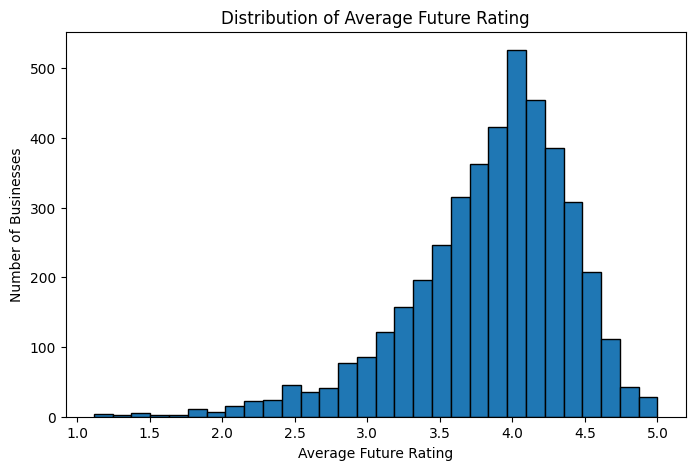

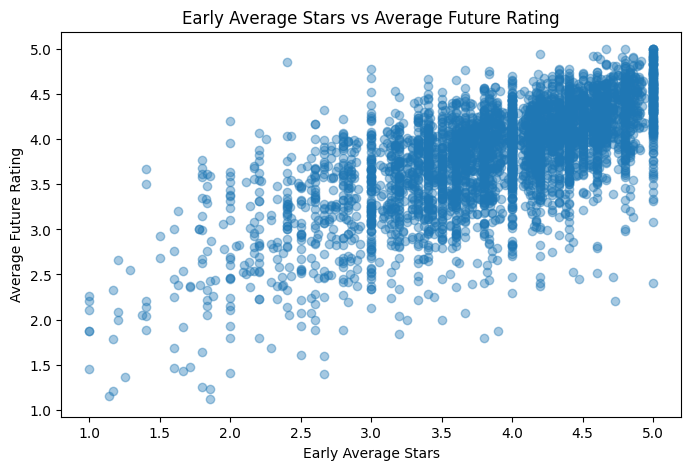

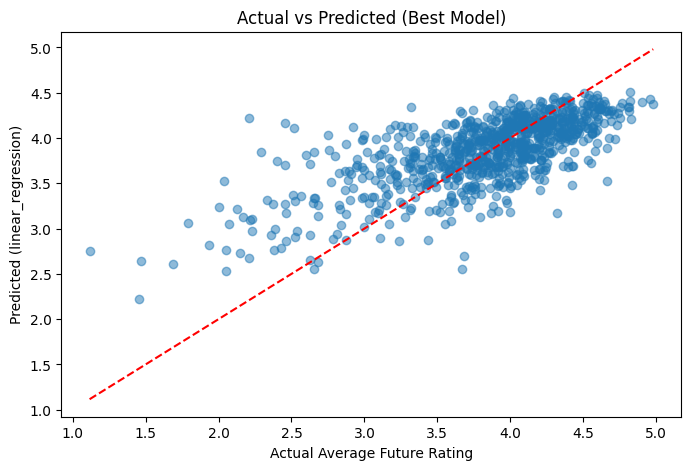

Best model: linear_regression
model            linear_regression
mae                       0.317618
rmse                      0.419409
r2                        0.486602
n_train                       3406
n_test                         852
n_features                      14
cv_mae_mean               0.319683
cv_mae_std                0.011162
cv_r2_mean                0.440819
cv_r2_std                 0.017444
cv_folds_used                    5
Name: 0, dtype: object


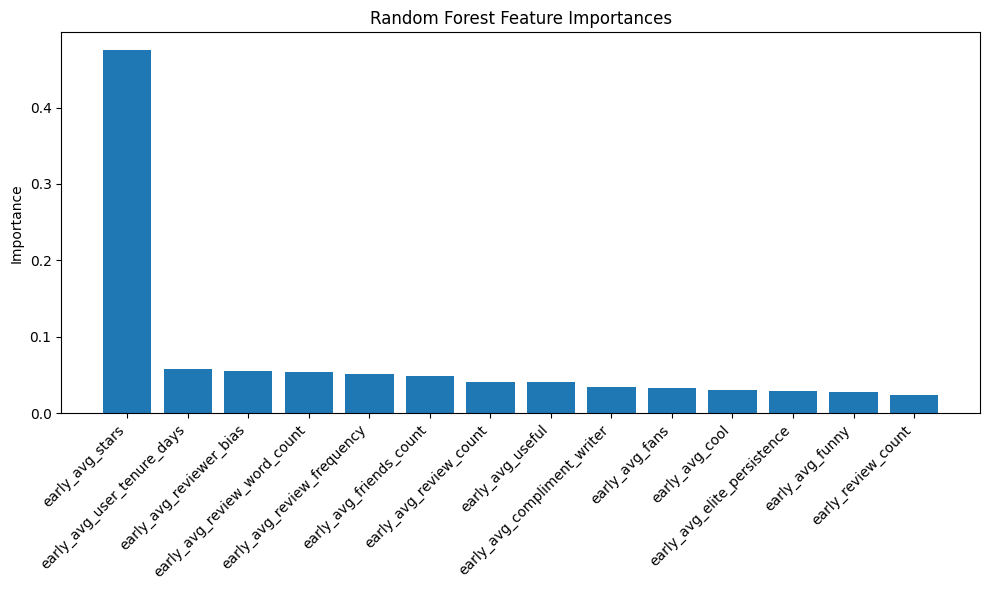

Top correlations with average_future_rating:


,feature,corr
0,early_avg_stars,0.669275
1,early_avg_reviewer_bias,0.593627
2,early_avg_cool,0.157205
3,early_avg_review_word_count,-0.150186
4,early_avg_user_tenure_days,0.118381
5,early_avg_friends_count,0.062436
6,early_avg_fans,0.061792
7,early_avg_elite_persistence,0.059140
8,early_review_count,0.057662
9,early_avg_review_count,0.030240


,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
31,-0TffRSXXIlBYVbb5AwfTg,4.0,0.916667,0.083333,0.5,75.083333,5.25,68.583333,4.666667,0.166667,946.916667,1.0,142.166667,8.416667,12,4.298368
40,-0iIxySkp97WNlwK66OGWg,4.6,2.200000,0.500000,1.7,128.100000,13.20,337.700000,15.700000,0.461000,902.700000,1.8,92.000000,33.400000,10,3.663636
47,-1B9pP_CrRBJYPICE5WbRA,3.5,0.000000,0.000000,0.1,56.100000,1.80,76.700000,0.300000,-0.706000,1033.900000,0.3,85.900000,14.900000,10,3.656489
57,-1XSzguS6XLN-V6MVZMg2A,4.9,2.700000,0.200000,1.4,50.900000,4.50,116.900000,0.500000,0.765000,1275.600000,0.7,92.000000,10.200000,10,4.665370
95,-3IOd5YntpkbK6RwT3HYtA,4.0,1.000000,0.000000,0.0,7.200000,0.00,18.400000,0.000000,0.280000,349.200000,0.0,78.400000,1.600000,5,3.600000


In [8]:
pipeline_output = run_prediction_pipeline(
    processed_dir=PROCESSED_DIR,
    cohort_year=COHORT_YEAR,
    early_window_days=EARLY_WINDOW_DAYS,
    future_window_end_day=FUTURE_WINDOW_END_DAY,
    period=PERIOD,
    min_early_reviews=MIN_EARLY_REVIEWS,
    min_future_reviews=MIN_FUTURE_REVIEWS,
    feature_file=FEATURE_FILE,
)

model_df = pipeline_output["model_df"]
feature_cols = pipeline_output["feature_cols"]
target_col = pipeline_output["target_col"]

print("Model dataset shape:", model_df.shape)
print("Target column:", target_col)
print("Number of features:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])
print("Sanity report:", pipeline_output["sanity_report"])
print("Regression summary:")
print(pipeline_output["regression_report"]["results_df"])

output_dir = PROCESSED_DIR / "modeling_tables"
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"business_level_{EARLY_WINDOW_DAYS}D_{FUTURE_WINDOW_END_DAY}D_{PERIOD}.csv"
model_df.to_csv(output_path, index=False, float_format="%.4f")
print("Saved modeling table to:", output_path.resolve())

results_package = generate_results_package(
    pipeline_output=pipeline_output,
    target_col=target_col,
    top_n_correlations=15,
    show_plots=True,
)

print("Top correlations with average_future_rating:")
display(results_package["correlation_table"])

model_df.head()

In [9]:
# Exploratory Tables and Graphs
# Summary stats, head, and missing values
import pandas as pd

print("Model dataset shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())

print("\nSummary statistics:")
print(model_df.describe())

print("\nMissing values per column:")
print(model_df.isnull().sum())

print("\nFirst 5 rows:")
model_df.head()

Model dataset shape: (4258, 16)

Columns:
['business_id', 'early_avg_stars', 'early_avg_useful', 'early_avg_funny', 'early_avg_cool', 'early_avg_review_count', 'early_avg_fans', 'early_avg_friends_count', 'early_avg_compliment_writer', 'early_avg_reviewer_bias', 'early_avg_user_tenure_days', 'early_avg_elite_persistence', 'early_avg_review_word_count', 'early_avg_review_frequency', 'early_review_count', 'average_future_rating']

Summary statistics:
       early_avg_stars  early_avg_useful  early_avg_funny  early_avg_cool  \
count      4258.000000       4258.000000      4258.000000     4258.000000   
mean          3.907392          1.426075         0.406181        0.592195   
std           0.724164          1.410772         0.600276        0.875491   
min           1.000000          0.000000         0.000000        0.000000   
25%           3.500000          0.500000         0.000000        0.125000   
50%           4.000000          1.000000         0.200000        0.333333   
75%     

,business_id,early_avg_stars,early_avg_useful,early_avg_funny,early_avg_cool,early_avg_review_count,early_avg_fans,early_avg_friends_count,early_avg_compliment_writer,early_avg_reviewer_bias,early_avg_user_tenure_days,early_avg_elite_persistence,early_avg_review_word_count,early_avg_review_frequency,early_review_count,average_future_rating
31,-0TffRSXXIlBYVbb5AwfTg,4.0,0.916667,0.083333,0.5,75.083333,5.25,68.583333,4.666667,0.166667,946.916667,1.0,142.166667,8.416667,12,4.298368
40,-0iIxySkp97WNlwK66OGWg,4.6,2.200000,0.500000,1.7,128.100000,13.20,337.700000,15.700000,0.461000,902.700000,1.8,92.000000,33.400000,10,3.663636
47,-1B9pP_CrRBJYPICE5WbRA,3.5,0.000000,0.000000,0.1,56.100000,1.80,76.700000,0.300000,-0.706000,1033.900000,0.3,85.900000,14.900000,10,3.656489
57,-1XSzguS6XLN-V6MVZMg2A,4.9,2.700000,0.200000,1.4,50.900000,4.50,116.900000,0.500000,0.765000,1275.600000,0.7,92.000000,10.200000,10,4.665370
95,-3IOd5YntpkbK6RwT3HYtA,4.0,1.000000,0.000000,0.0,7.200000,0.00,18.400000,0.000000,0.280000,349.200000,0.0,78.400000,1.600000,5,3.600000


In [10]:
# Correlation with target: top features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if "average_future_rating" in numeric_cols:
    corr_series = model_df[numeric_cols].corr()["average_future_rating"].drop("average_future_rating")
    corr_top = corr_series.abs().sort_values(ascending=False).head(15)
    print("Top correlations with average_future_rating (by absolute value):")
    display(pd.DataFrame({"feature": corr_top.index, "corr": corr_top.values}))
else:
    print("average_future_rating not in numeric columns; skipping correlation summary.")

Top correlations with average_future_rating (by absolute value):


,feature,corr
0,early_avg_stars,0.669275
1,early_avg_reviewer_bias,0.593627
2,early_avg_cool,0.157205
3,early_avg_review_word_count,0.150186
4,early_avg_user_tenure_days,0.118381
5,early_avg_friends_count,0.062436
6,early_avg_fans,0.061792
7,early_avg_elite_persistence,0.059140
8,early_review_count,0.057662
9,early_avg_review_count,0.030240


ALL MODEL RESULTS
               model       mae      rmse        r2  n_train  n_test  n_features  cv_mae_mean  cv_mae_std  cv_r2_mean  cv_r2_std  cv_folds_used
0  linear_regression  0.317618  0.419409  0.486602     3406     852          14     0.319683    0.011162    0.440819   0.017444              5
1              ridge  0.317649  0.419434  0.486541     3406     852          14     0.319686    0.011184    0.440825   0.017454              5
2      random_forest  0.324851  0.433431  0.451699     3406     852          14     0.327504    0.010740    0.416053   0.018075              5
3            xgboost  0.332560  0.445107  0.421762     3406     852          14     0.333954    0.009260    0.389616   0.018162              5
4      baseline_mean  0.441221  0.585802 -0.001568     3406     852          14     0.429057    0.011864   -0.003020   0.002951              5



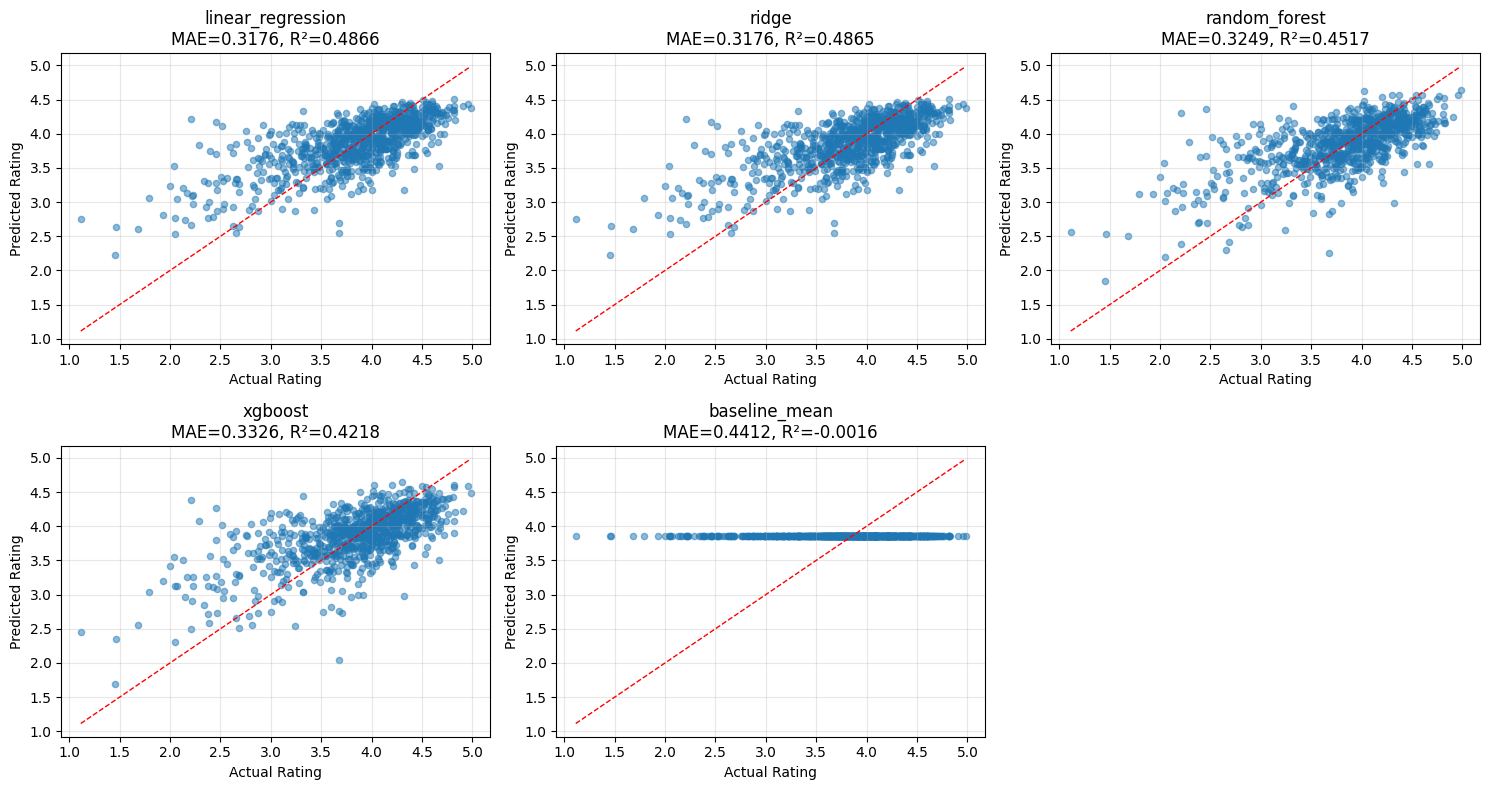

In [11]:
# Model Results: All models with predicted vs actual plots
import numpy as np

results_df = pipeline_output["regression_report"]["results_df"]
predictions_df = pipeline_output["regression_report"]["predictions_df"].copy()

print("=" * 80)
print("ALL MODEL RESULTS")
print("=" * 80)
print(results_df.to_string())
print()

y_true = predictions_df["average_future_rating"].values
min_val = float(y_true.min())
max_val = float(y_true.max())

# Plot predicted vs actual for each model
num_models = len(results_df)
n_cols = 3
n_rows = (num_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # flatten to 1D array for easier iteration

for idx, (_, row) in enumerate(results_df.iterrows()):
    model_name = row["model"]
    mae = row["mae"]
    r2 = row["r2"]
    
    # Get predictions for this model
    if model_name == "baseline_mean":
        pred_col = "pred_baseline_mean"
    else:
        pred_col = f"pred_{model_name}"
    
    if pred_col not in predictions_df.columns:
        print(f"Warning: {pred_col} not found in predictions_df")
        continue
    
    y_pred = predictions_df[pred_col].values
    
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="red", linewidth=1)
    ax.set_xlabel("Actual Rating")
    ax.set_ylabel("Predicted Rating")
    ax.set_title(f"{model_name}\nMAE={mae:.4f}, R²={r2:.4f}")
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(num_models, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


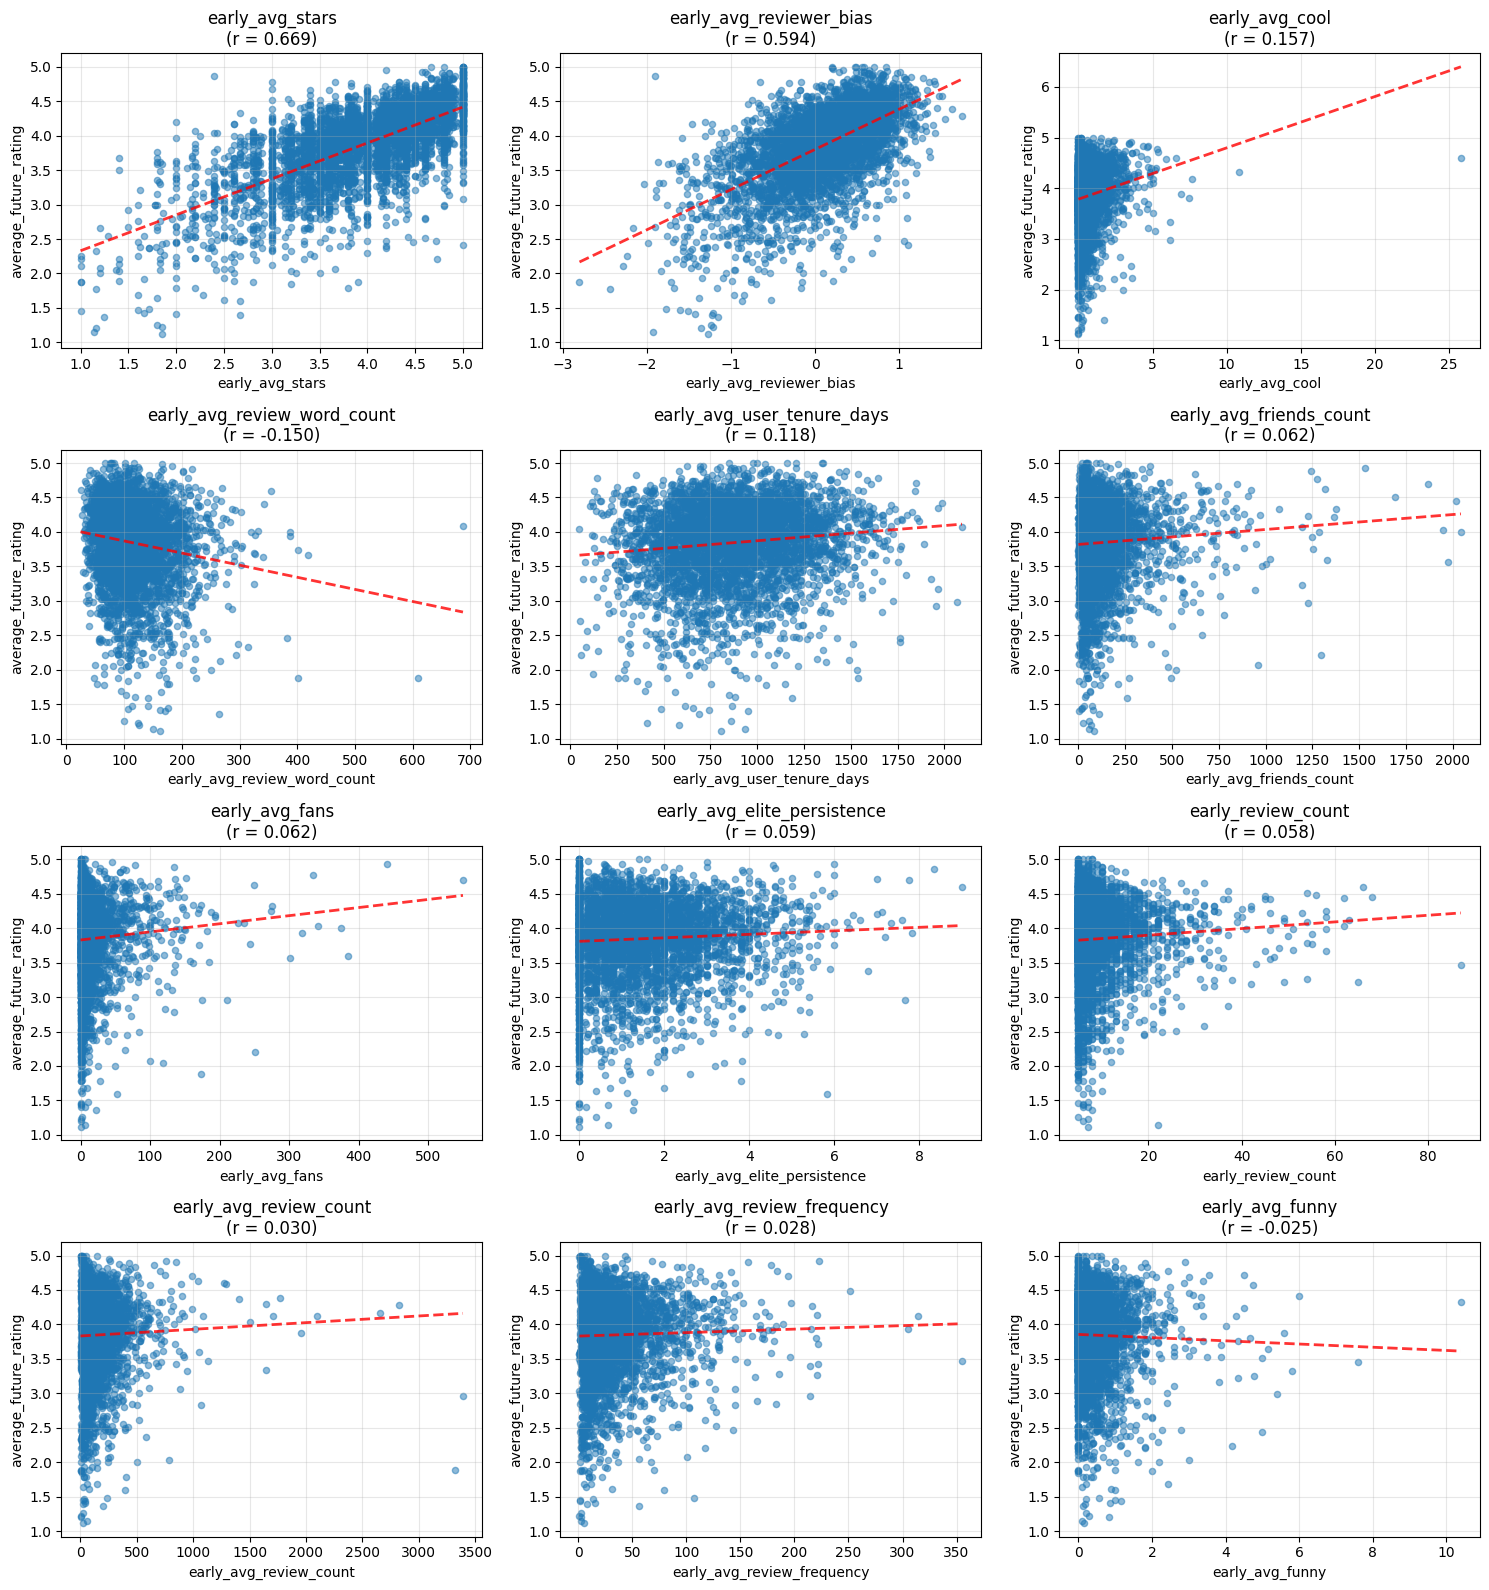

In [12]:
# Top Features vs Target Relationships
from scipy import stats

# Get top correlated features
numeric_cols = model_df.select_dtypes(include="number").columns.tolist()
if target_col in numeric_cols:
    corr_with_target = model_df[numeric_cols].corr()[target_col].drop(target_col)
    top_features = corr_with_target.abs().sort_values(ascending=False).head(12).index.tolist()
    
    # Create scatter plots for top features
    n_features = len(top_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for idx, feature in enumerate(top_features):
        ax = axes[idx]
        
        # Scatter plot
        ax.scatter(model_df[feature], model_df[target_col], alpha=0.5, s=20)
        
        # Add trend line
        z = np.polyfit(model_df[feature].dropna(), model_df[target_col].loc[model_df[feature].notna()], 1)
        p = np.poly1d(z)
        x_line = np.linspace(model_df[feature].min(), model_df[feature].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        # Calculate correlation
        corr_coef = corr_with_target[feature]
        
        ax.set_xlabel(feature)
        ax.set_ylabel(target_col)
        ax.set_title(f"{feature}\n(r = {corr_coef:.3f})")
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"{target_col} not in numeric columns; skipping feature vs target analysis.")
